In [104]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings            
warnings.filterwarnings("ignore") 

# Load and Check Data <a id="-1"></a>

In [105]:
y_2018 = pd.read_csv("E:/KEC/CSV_Files/Data/2018.csv");
y_2019 = pd.read_csv("E:/KEC/CSV_Files/Data/2019.csv");

data = pd.concat([y_2018,y_2019],sort=False)
data

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.408
3,4,Iceland,7.495,1.343,1.644,0.914,0.677,0.353,0.138
4,5,Switzerland,7.487,1.420,1.549,0.927,0.660,0.256,0.357
...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035


# Veriable Description

1. Overall rank: Ranking of countries by happiness level
2. Country or region: Country or region names
3. Score: Happiness scores
4. GDP per capita: Value representing the country's income and expense levels
5. Social support
6. Healthy life expectancy
7. Freedom to make life choices
8. Generosity
9. Perceptions of corruption

In [106]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Overall rank,312.0,78.500000,45.104737,1.000,39.75000,78.5000,117.25000,156.000
Score,312.0,5.391506,1.114631,2.853,4.51425,5.3795,6.17600,7.769
GDP per capita,312.0,0.898298,0.394592,0.000,0.60950,0.9600,1.21950,2.096
Social support,312.0,1.211026,0.300310,0.000,1.05575,1.2655,1.45750,1.644
Healthy life expectancy,312.0,0.661295,0.252724,0.000,0.48825,0.6990,0.85800,1.141
Freedom to make life choices,312.0,0.423538,0.156024,0.000,0.32250,0.4495,0.54025,0.724
Generosity,312.0,0.182926,0.096739,0.000,0.10875,0.1755,0.24500,0.598
Perceptions of corruption,311.0,0.111299,0.095365,0.000,0.05000,0.0820,0.14050,0.457


In [107]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 312 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  312 non-null    int64  
 1   Country or region             312 non-null    object 
 2   Score                         312 non-null    float64
 3   GDP per capita                312 non-null    float64
 4   Social support                312 non-null    float64
 5   Healthy life expectancy       312 non-null    float64
 6   Freedom to make life choices  312 non-null    float64
 7   Generosity                    312 non-null    float64
 8   Perceptions of corruption     311 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 24.4+ KB


Let's change the column names for convenience.

In [108]:
data.rename(columns={
    "Overall rank": "rank",
    "Country or region": "country",
    "Score": "score",
    "GDP per capita": "gdp",
    "Social support": "social",
    "Healthy life expectancy": "healthy",
    "Freedom to make life choices": "freedom",
    "Generosity": "generosity",
    "Perceptions of corruption": "corruption"
},inplace=True)
del data["rank"]

# Missing Value 

In [109]:
data.columns[data.isnull().any()]

Index(['corruption'], dtype='object')

There are empty elements in only one column. Let's look at how many.

In [110]:
data.isnull().sum()

country       0
score         0
gdp           0
social        0
healthy       0
freedom       0
generosity    0
corruption    1
dtype: int64

In [111]:
data[data["corruption"].isnull()]

,country,score,gdp,social,healthy,freedom,generosity,corruption
19,United Arab Emirates,6.774,2.096,0.776,0.67,0.284,0.186,NaN


In [112]:
# compute mean only for the numeric 'corruption' column to avoid trying to average the 'country' strings
avg_data_corruption = data.loc[data["score"] > 6.774, "corruption"].mean()

# fill missing corruption values with the computed average
data.loc[data["corruption"].isnull(), "corruption"] = avg_data_corruption

# verify there are no remaining nulls in 'corruption'
data[data["corruption"].isnull()]

,country,score,gdp,social,healthy,freedom,generosity,corruption


# Data Preparation <a id="0"></a>
## Inconsistent Observation
* 95% of a machine learning model is said to be preprocessing and 5% is model selection. For this we need to teach the data to the model correctly. In order to prepare the available data for machine learning, we must apply certain pre-processing methods. One of these methods is the analysis of outliers. The outlier is any data point that is substantially different from the rest of the observations in a data set. In other words, it is the observation that goes far beyond the general trend.

![](https://miro.medium.com/max/854/1*RW-vfIbKZh-UGsLfTAWpyw.png)

Outlier values behave differently from other data models and they increase the error with overfitting, so the outlier model must be detected and some operations must be performed on it.
### 1.Using Box Graph
We can see contradictory observations with many visualization techniques. One of them is the box chart. If there is an outlier, this is drawn as the point, but the other population is grouped together and displayed in boxes.

In [113]:
df = data.copy()
df = df.select_dtypes(include=["float64","int64"])
df.head()

,score,gdp,social,healthy,freedom,generosity,corruption
0,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,7.594,1.456,1.582,0.861,0.686,0.286,0.340
2,7.555,1.351,1.590,0.868,0.683,0.284,0.408
3,7.495,1.343,1.644,0.914,0.677,0.353,0.138
4,7.487,1.420,1.549,0.927,0.660,0.256,0.357


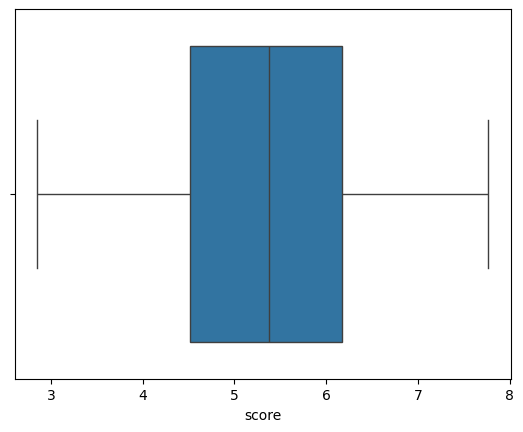

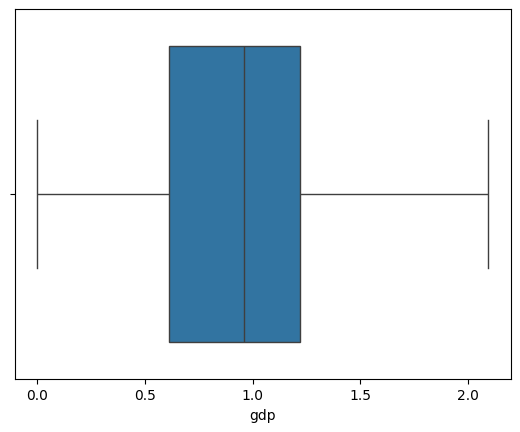

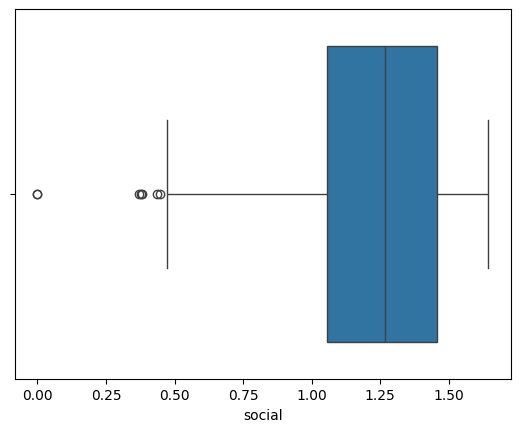

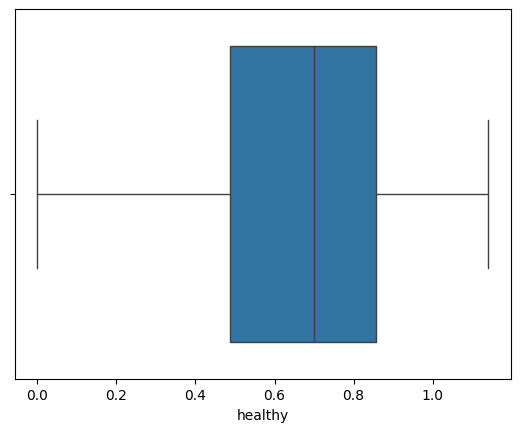

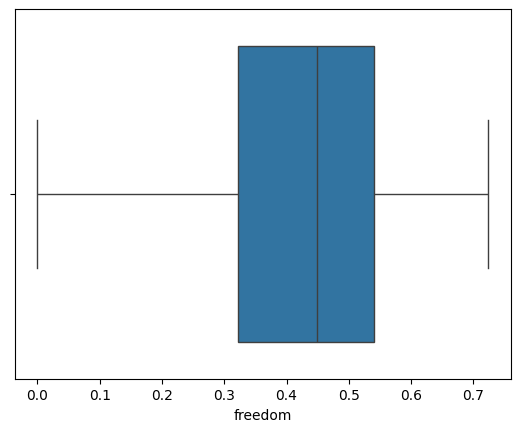

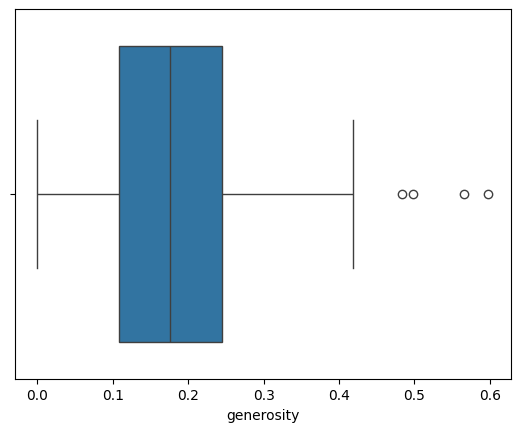

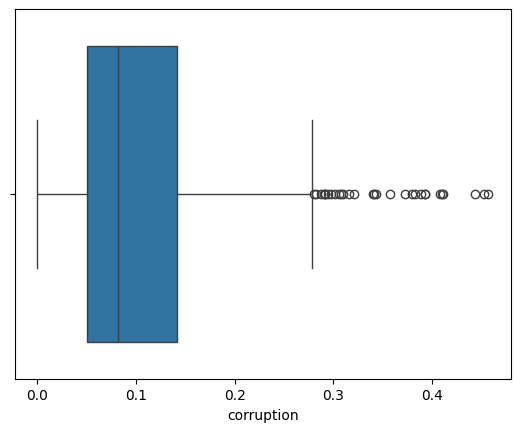

In [114]:
column_list = ["score","gdp","social","healthy","freedom","generosity","corruption"]
for col in column_list:
    sns.boxplot(x = df[col])
    plt.xlabel(col)
    plt.show()

We have observed that there are outliers in the "social" and "corruption" column. This may cause us to negatively affect us while training our data set.

In [115]:
# for corruption
df_table = df["corruption"]

Q1 = df_table.quantile(0.25)
Q3 = df_table.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
print("lower bound is " + str(lower_bound))
print("upper bound is " + str(upper_bound))
print("Q1: ", Q1)
print("Q3: ", Q3)

lower bound is -0.08687499999999997
upper bound is 0.27812499999999996
Q1:  0.05
Q3:  0.14125


In [116]:
outliers_vector = (df_table < (lower_bound)) | (df_table > (upper_bound))
outliers_vector

0       True
1       True
2       True
3      False
4       True
       ...  
151     True
152    False
153    False
154    False
155    False
Name: corruption, Length: 312, dtype: bool

In [117]:
outliers_vector = df_table[outliers_vector]
outliers_vector.index.values

array([  0,   1,   2,   4,   5,   6,   7,   8,   9,  13,  14,  16,  33,
        75,  97, 150,   0,   1,   2,   4,   5,   6,   7,   8,  10,  13,
        15,  33,  75, 151])

Deleting data is not suitable for this data set. That's why we will fill out the outliers with the average.

In [118]:
df_table = data.copy()
df_table["corruption"].iloc[outliers_vector.index.values] = df_table["corruption"].mean()
df_table["corruption"].iloc[outliers_vector.index.values]

0      0.111794
1      0.111794
2      0.111794
4      0.111794
5      0.111794
6      0.111794
7      0.111794
8      0.111794
9      0.111794
13     0.111794
14     0.111794
16     0.111794
33     0.111794
75     0.111794
97     0.111794
150    0.111794
0      0.111794
1      0.111794
2      0.111794
4      0.111794
5      0.111794
6      0.111794
7      0.111794
8      0.111794
10     0.111794
13     0.111794
15     0.111794
33     0.111794
75     0.111794
151    0.111794
Name: corruption, dtype: float64

In [119]:
data = df_table

# Simple Linear Regressions <a id="1"></a>
Simple linear regression is a statistical method that allows us to summarize and analyze the relationships between two continuous (quantitative) variables:

## score - gdp
Firstly let's observe the relationship between gdp and score with the help of graphics.
* independent variable : x
* dependent variable : y

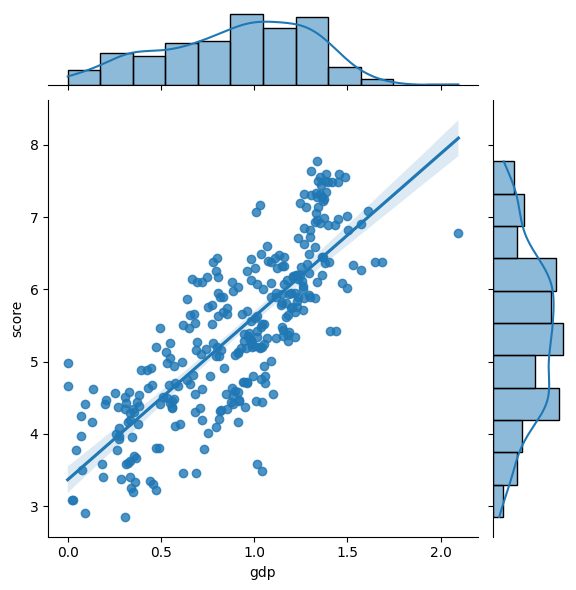

In [120]:
sns.jointplot(x="gdp",y="score",data=df_table,kind="reg")
plt.show()

In [121]:
from sklearn.linear_model import LinearRegression

X = data[["gdp"]]
X.head

<bound method NDFrame.head of        gdp
0    1.305
1    1.456
2    1.351
3    1.343
4    1.420
..     ...
151  0.359
152  0.476
153  0.350
154  0.026
155  0.306

[312 rows x 1 columns]>

In [122]:
y = data[["score"]]
y.head

<bound method NDFrame.head of      score
0    7.632
1    7.594
2    7.555
3    7.495
4    7.487
..     ...
151  3.334
152  3.231
153  3.203
154  3.083
155  2.853

[312 rows x 1 columns]>

In [123]:
reg = LinearRegression()
model = reg.fit(X,y)
print("intercept: ", model.intercept_)
print("coef: ", model.coef_)
print("rscore. ", model.score(X,y))

intercept:  [3.36665334]
coef:  [[2.25409931]]
rscore.  0.6367680251195654


rscore meaning:
* For example, the gdp argument used here describes 63% of the data.

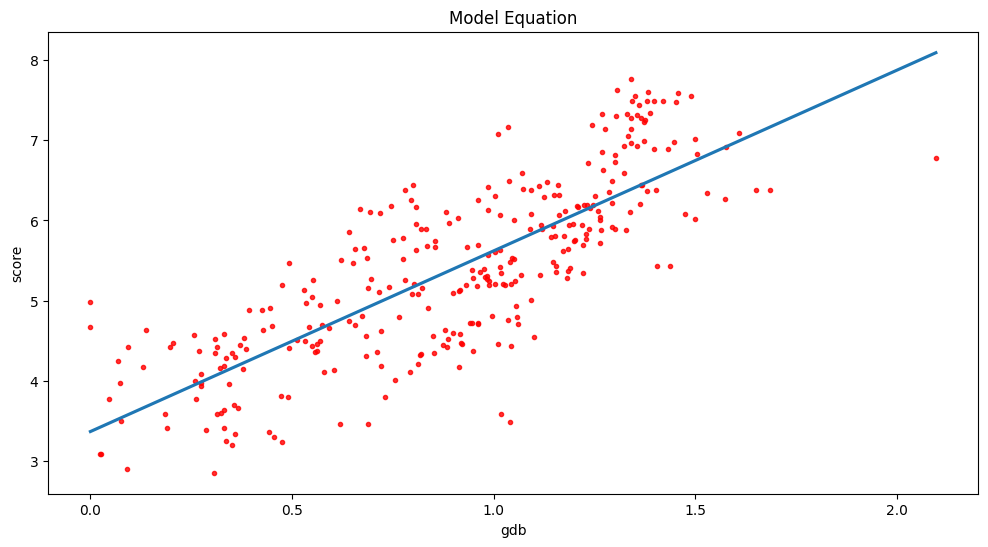

In [124]:
# prediction
plt.figure(figsize=(12,6))
g = sns.regplot(x=data["gdp"],y=data["score"],ci=None,scatter_kws = {'color':'r','s':9})
g.set_title("Model Equation")
g.set_ylabel("score")
g.set_xlabel("gdb")
plt.show()

What we want to do here is; For example, to answer the question of what is the happiness level of a country with a gdp value of 1. In other words, to estimate the desired value with the existing data set.

In [125]:
# model.intercep_ + model.coef_ * 1
model.predict([[1]])

array([[5.62075264]])

In [126]:
gdb_list = [[0.25],[0.50],[0.75],[1.00],[1.25],[1.50]]
model.predict(gdb_list)
for g in gdb_list:
    print("The happiness value of the country with a gdp value of ",g,": ",model.predict([g]))

The happiness value of the country with a gdp value of  [0.25] :  [[3.93017816]]
The happiness value of the country with a gdp value of  [0.5] :  [[4.49370299]]
The happiness value of the country with a gdp value of  [0.75] :  [[5.05722782]]
The happiness value of the country with a gdp value of  [1.0] :  [[5.62075264]]
The happiness value of the country with a gdp value of  [1.25] :  [[6.18427747]]
The happiness value of the country with a gdp value of  [1.5] :  [[6.7478023]]


Let's create a class and make the job easier.

In [127]:
def linear_reg(col,text,prdctn):
    
    sns.jointplot(x=col,y="score",data=df_table,kind="reg")
    plt.show()
    
    X = data[[col]]
    y = data[["score"]]
    reg = LinearRegression()
    model = reg.fit(X,y)
    
    # prediction
    plt.figure(figsize=(12,6))
    g = sns.regplot(x=data[col],y=data["score"],ci=None,scatter_kws = {'color':'r','s':9})
    g.set_title("Model Equation")
    g.set_ylabel("score")
    g.set_xlabel(col)
    plt.show()
    
    print(text,": ", model.predict([[prdctn]]))

## score - social

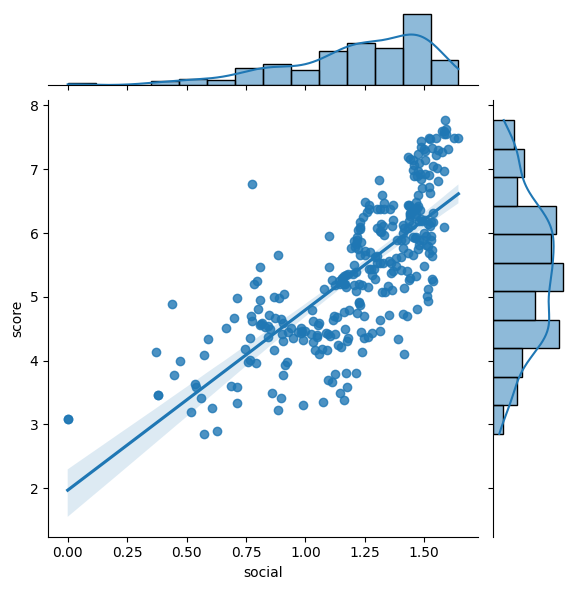

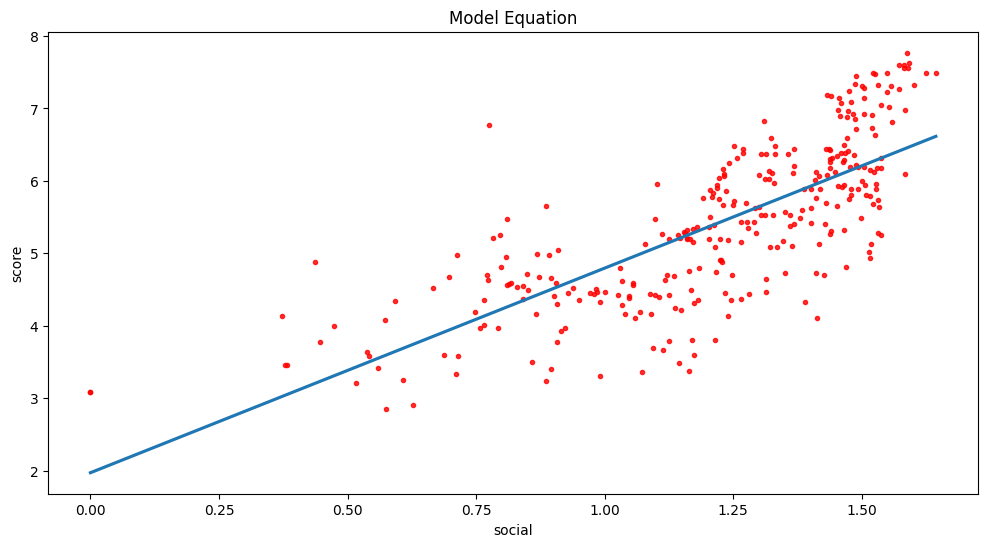

The happiness value of the country whose sociability value is 2: :  [[7.62022176]]


In [128]:
linear_reg("social","The happiness value of the country whose sociability value is 2:",2)

In [129]:
column_list = ["score","gdp","social","healthy","freedom","generosity","corruption"]

## score - healthy

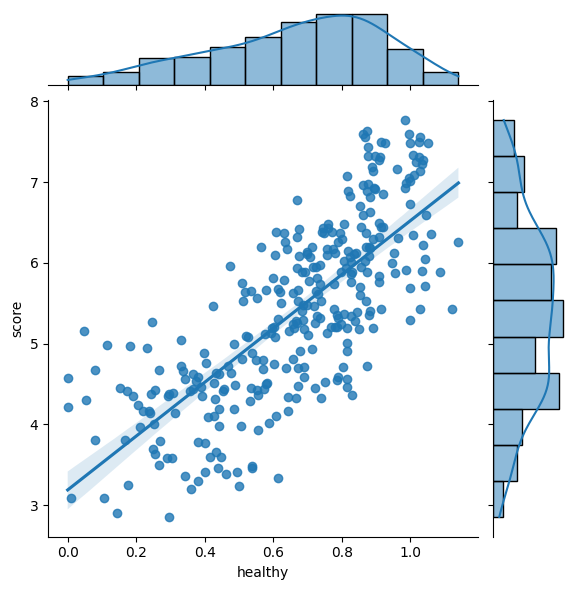

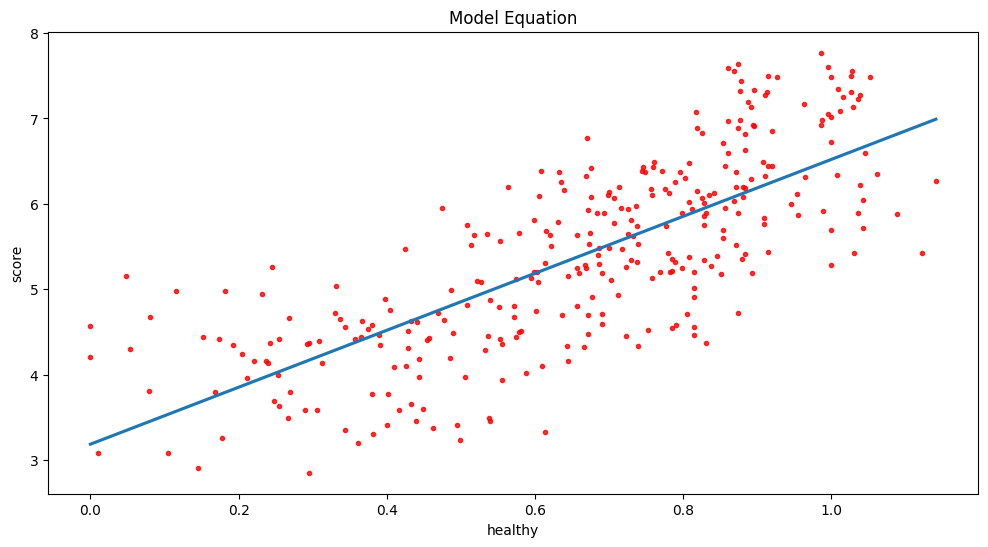

The happiness value of the country whose healthiest value is 1.20: :  [[7.18742031]]


In [130]:
linear_reg("healthy","The happiness value of the country whose healthiest value is 1.20:",1.20)

## score - freedom

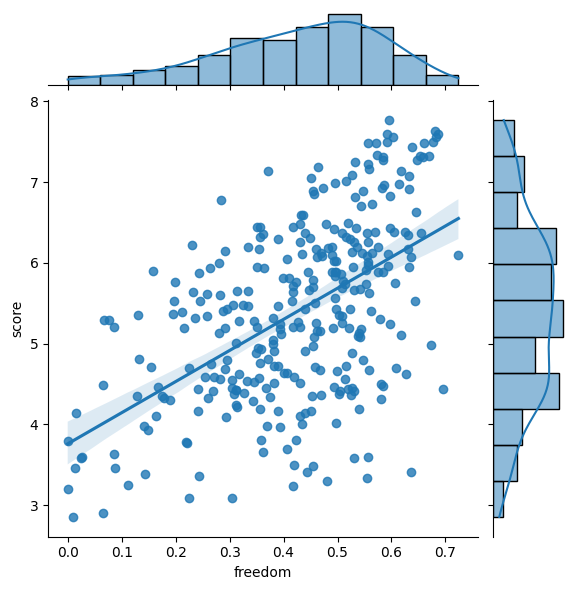

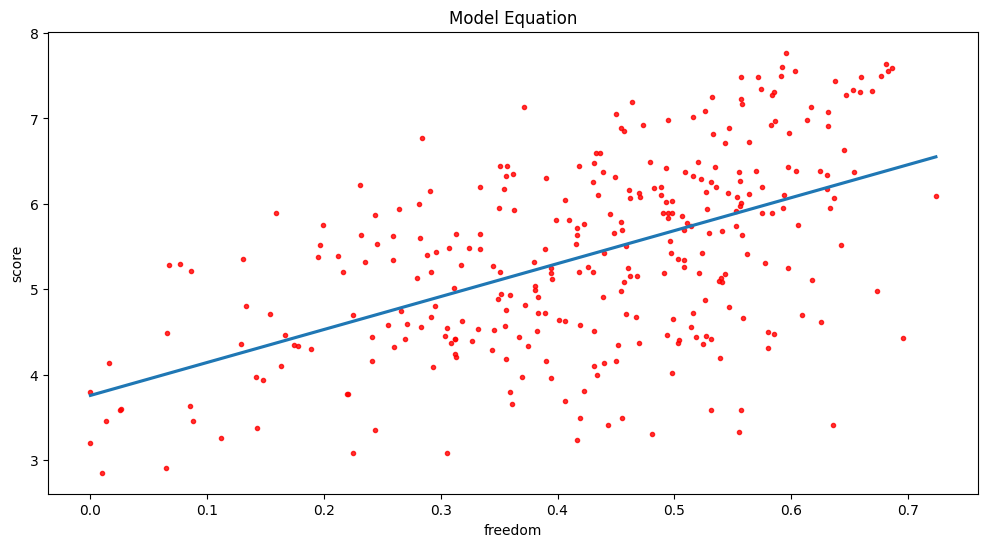

The happiness value of the country whose freedom value is 0.89: :  [[7.190655]]


In [131]:
linear_reg("freedom","The happiness value of the country whose freedom value is 0.89:",0.89)

# Multiple Linear Regression <a id="2"></a>
The main purpose is to find the linear function that expresses the relationship between dependent and independent variables.

In [132]:
import statsmodels.api as sms

X = df.drop("score",axis=1)
y = df["score"]

# OLS(dependent,independent)
lm = sms.OLS(y,X)
model = lm.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  score   R-squared (uncentered):                   0.986
Model:                            OLS   Adj. R-squared (uncentered):              0.986
Method:                 Least Squares   F-statistic:                              3622.
Date:                Wed, 10 Dec 2025   Prob (F-statistic):                   7.57e-281
Time:                        11:42:32   Log-Likelihood:                         -307.69
No. Observations:                 312   AIC:                                      627.4
Df Residuals:                     306   BIC:                                      649.8
Df Model:                           6                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
gdp            0.5774      0.178      3.238      0.001       0.226       0.928
social         2.2624      0.153     14.780      0.000       1.961       2.564
healthy        1.2506      0.260      4.805      0.000       0.738       1.763
freedom        1.8640      0.289      6.447      0.000       1.295       2.433
generosity     2.0380      0.399      5.109      0.000       1.253       2.823
corruption     0.5464      0.468      1.169      0.243      -0.374       1.466
==============================================================================
Omnibus:                        6.324   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.042   Jarque-Bera (JB):                7.204
Skew:                           0.212   Prob(JB):                       0.0273
Kurtosis:                       3.612   Cond. No.                         24.4
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

R-squared: Percentages of independent variables that explain the change in dependent variables. <br>
F-statistic: Expresses the significance of the model. <br>
coef: refers to coefficients. <br>
std err: standard errors. <br><br>

Here we can make the following comments.
- When the gdp value is increased by 1, the score increases by 0.8114.
- When there is an increase of 1 unit from the social value, the score increases by 1.9740.
...

In [133]:
# create model with sckit learn

lm = LinearRegression()
model = lm.fit(X,y)
print("constant: ",model.intercept_)
print("coefficient: ",model.coef_)

constant:  1.8541077926951228
coefficient:  [0.929921   1.06504217 0.94321492 1.40426054 0.52070628 0.88114008]


In [134]:
# PREDICTION
# Score = 0.929921*gdp + 1.06504217*social + 0.94321492*healthy + 1.40426054*freedom + 0.52070628*generosity + 0.88114008*corruption

new_data = [[1],[2],[1.25],[1.75],[1.50],[0.75]]
new_data = pd.DataFrame(new_data).T
new_data

,0,1,2,3,4,5
0,1.0,2.0,1.25,1.75,1.5,0.75


In [135]:
model.predict(new_data)

array([9.99250222])

In [136]:
# calculating the amount of error

from sklearn.metrics import mean_squared_error

MSE = mean_squared_error(y,model.predict(X))
RMSE = np.sqrt(MSE)

print("MSE: ", MSE)
print("RMSE: ", RMSE)

MSE:  0.26768307316350287
RMSE:  0.5173809748758673


# Simple Linear & Multiple Linear Regression - Model Tuning <a id="3"></a>

In [137]:
from sklearn.model_selection import train_test_split

X = df.drop("score",axis=1)
y = df["score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head()

,gdp,social,healthy,freedom,generosity,corruption
111,0.916,0.817,0.790,0.419,0.149,0.032
52,1.187,1.465,0.812,0.264,0.075,0.064
145,1.017,1.174,0.417,0.557,0.042,0.092
47,1.162,1.232,0.825,0.462,0.083,0.005
78,1.154,1.202,0.879,0.131,0.000,0.044


In [138]:
X_test.head()

,gdp,social,healthy,freedom,generosity,corruption
72,1.051,1.361,0.871,0.197,0.142,0.080
9,1.340,1.573,0.910,0.647,0.361,0.302
57,1.229,1.211,0.909,0.495,0.179,0.154
60,1.229,1.191,0.909,0.423,0.202,0.035
25,1.365,1.436,0.857,0.418,0.151,0.078


In [139]:
y_train.head()

111    4.586
52     5.940
145    3.590
47     6.070
78     5.358
Name: score, dtype: float64

In [140]:
y_test.head()

72    5.523
9     7.272
57    5.835
60    5.762
25    6.441
Name: score, dtype: float64

In [141]:
lm = LinearRegression()
lm.fit(X_train, y_train)
print("Training error",np.sqrt(mean_squared_error(y_train,model.predict(X_train))))
print("Test error",np.sqrt(mean_squared_error(y_test,model.predict(X_test))))

Training error 0.5286863282545513
Test error 0.4700442336475784


Every time we change the random_state value we defined at first, a different result is returned. We need to find out which of these returns the best result. For this we need to do the following.

In [142]:
from sklearn.model_selection import cross_val_score

cross_val_score(model, X_train, y_train, cv=10, scoring="neg_mean_squared_error")

array([-0.38049606, -0.23987782, -0.24029   , -0.41370114, -0.16258143,
       -0.37149593, -0.25642041, -0.39761278, -0.21403289, -0.29719585])

In [143]:
cvs_avg_mse = np.mean(-cross_val_score(model, X_train, y_train, cv=20, scoring="neg_mean_squared_error"))
cvs_avg_rmse = np.sqrt(cvs_avg_mse)

print("Cross Val Score MSE = ",cvs_avg_mse)
print("Cross Val Score RMSE = ",cvs_avg_rmse)

Cross Val Score MSE =  0.2945486894707848
Cross Val Score RMSE =  0.5427234005188875


# Ridge Regression <a id="4"></a>
The aim is to find the coefficients that minimize the sum of error squares by applying a penalty to these coefficients.
* It is resistant to over learning.
* It is biased but its variance is low.
* It is better than OLS when there are too many parameters.
* Builds a model with all variables. It does not exclude the unrelated variables from the model, it approximates its coefficients to zero.

![](https://i.ibb.co/2SJtqyB/Ek-A-klama-2020-04-21-202339.jpg)

* The delta parameter that gives the smallest "cross validation" value is selected.
* With this delta selected, the model is fit for observations again.

## Ridge Regression - Model

In [144]:
# Required Libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn.linear_model import RidgeCV

In [145]:
X = df.drop("score",axis=1)
y = df["score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ridge_model = Ridge(alpha=0.1).fit(X_train, y_train)
ridge_model

,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [146]:
ridge_model.coef_

array([0.94225637, 1.02043421, 0.93689001, 1.44712035, 0.35979844,
       0.97107389])

An alpha value will be assigned with each coefficient. Error coefficients will be examined according to these values.

In [147]:
ridge_model.intercept_

np.float64(1.9108156265652139)

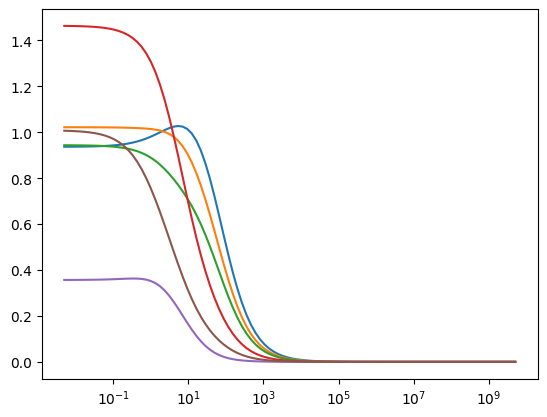

In [148]:
lambdas = 10**np.linspace(10,-2,100)*0.5 # Creates random numbers
ridge_model =  Ridge()
coefs = []

for i in lambdas:
    ridge_model.set_params(alpha=i)
    ridge_model.fit(X_train,y_train)
    coefs.append(ridge_model.coef_)
    
ax = plt.gca()
ax.plot(lambdas, coefs)
ax.set_xscale("log")

In contrast to the different beta values, the changes in the coefficients of the variables in our data set appear in the graph above. As can be seen, as the coefficients increase, it approaches zero.

## Ridge Regression - Prediction

In [149]:
ridge_model = Ridge().fit(X_train,y_train)

y_pred = ridge_model.predict(X_train)

print("predict: ", y_pred[0:10])
print("real: ", y_train[0:10].values)

predict:  [5.05318836 5.79071673 5.37059901 5.75868845 5.33588452 5.47787414
 5.95562654 5.72047349 6.84044342 6.15987674]
real:  [4.586 5.94  3.59  6.07  5.358 5.208 5.79  5.191 7.328 6.375]


In [150]:
RMSE = np.mean(mean_squared_error(y_train,y_pred)) # rmse = square root of the mean of error squares
print("train error: ", RMSE)

train error:  0.2806718934452946


In [151]:
Verified_RMSE = np.sqrt(np.mean(-cross_val_score(ridge_model, X_train, y_train, cv=20, scoring="neg_mean_squared_error")))
print("Verified_RMSE: ", Verified_RMSE)

Verified_RMSE:  0.5410728899647692


There are two values ​​above. One of them is unverified, the other is the values ​​that represent the square root of the sum of the verified error squares. As you can see, the unverified value is almost half of the verified value. This result shows us that it is more correct to use the second method, not the first method, while taking the square root of the mean of the error squares.

In [152]:
# test error
y_pred = ridge_model.predict(X_test)
RMSE = np.mean(mean_squared_error(y_test,y_pred))
print("test error: ", RMSE)

test error:  0.22371217702527907


## Ridge Model - Model Tuning

In [153]:
ridge_model = Ridge(10).fit(X_train,y_train)
y_pred = ridge_model.predict(X_test)
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(0.5102254754869215)

In [154]:
ridge_model = Ridge(30).fit(X_train,y_train)
y_pred = ridge_model.predict(X_test)
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(0.5983602488673111)

In [155]:
ridge_model = Ridge(90).fit(X_train,y_train)
y_pred = ridge_model.predict(X_test)
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(0.771024851567394)

We can find out which value will work better by trial and error. But with the method we will use below, we can find the most appropriate value more easily and quickly.

In [156]:
lambdas1 = 10**np.linspace(10,-2,100)
lambdas2 = np.random.randint(0,1000,100)

# 'normalize' was removed from RidgeCV in recent scikit-learn versions.
# Remove normalize=True. If you need scaling, scale X_train/X_test with StandardScaler before fitting.
ridgeCV = RidgeCV(alphas = lambdas1, scoring = "neg_mean_squared_error", cv=10)
ridgeCV.fit(X_train, y_train)

,alphas,array([1.0000...00000000e-02])
,fit_intercept,True
,scoring,'neg_mean_squared_error'
,cv,10
,gcv_mode,None
,store_cv_results,False
,alpha_per_target,False


We can use alpha_ feature to attract the most appropriate value.

In [157]:
ridgeCV.alpha_

np.float64(0.8697490026177834)

In [158]:
# final model
ridge_tuned = Ridge(alpha = ridgeCV.alpha_).fit(X_train,y_train)
y_pred = ridge_tuned.predict(X_test)
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(0.47288525297349676)

In [159]:
# for lambdas2
# 'normalize' parameter was removed from RidgeCV in recent scikit-learn versions.
# If you need feature scaling, apply StandardScaler to X_train/X_test before fitting.
ridgeCV = RidgeCV(alphas=lambdas2, scoring="neg_mean_squared_error", cv=10)
ridgeCV.fit(X_train, y_train)
ridge_tuned = Ridge(alpha=ridgeCV.alpha_).fit(X_train, y_train)
y_pred = ridge_tuned.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(0.47509096110915733)

# Lasso Regression <a id="5"></a>
The aim is to find the coefficients that minimize the sum of error squares by applying a penalty to these coefficients.
* Lasso regression = L1
* Ridge regression = L2

* It has been proposed to eliminate the disadvantage of leaving the related-unrelated variables in the model of the Ridge regression.
* Coefficients near zero in Lasso.
* But when the L1 norm is big enough in lambda, some coefficients make it zero. Thus, it makes the selection of the variable.
* It is very important to choose Lambda correctly, CV is used here too.
* Ridge and Lasso methods are not superior to each other.

## Lasso Regression - Model 

In [160]:
# Required Libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge,Lasso
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import model_selection
from sklearn.linear_model import RidgeCV, LassoCV

In [161]:
X = df.drop("score",axis=1)
y = df["score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

lasso_model = Lasso().fit(X_train,y_train)

In [162]:
print("intercept: ", lasso_model.intercept_)
print("coef: ", lasso_model.coef_)

intercept:  5.346196172248804
coef:  [0. 0. 0. 0. 0. 0.]


In [163]:
# coefficients for different lambda values

alphas = np.random.randint(0,10000,10)
lasso = Lasso()
coefs = []

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X_train,y_train)
    coefs.append(lasso.coef_)

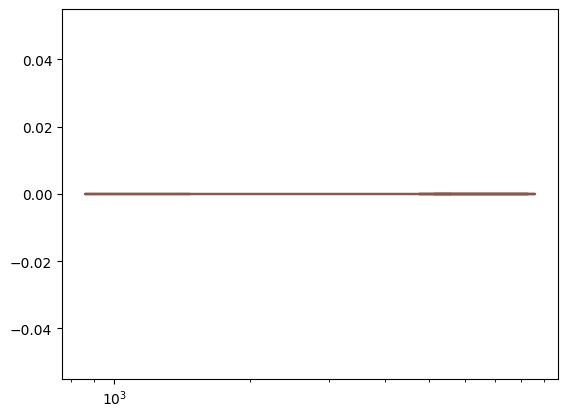

In [164]:
ax = plt.gca()
ax.plot(alphas,coefs)
ax.set_xscale("log")

## Lasso Regression - Prediction

In [165]:
lasso_model

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [166]:
lasso_model.predict(X_train)[0:5]

array([5.34619617, 5.34619617, 5.34619617, 5.34619617, 5.34619617])

In [167]:
lasso_model.predict(X_test)[0:5]

array([5.34619617, 5.34619617, 5.34619617, 5.34619617, 5.34619617])

In [168]:
y_pred = lasso_model.predict(X_test)
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(1.1087763155347463)

In [169]:
r2_score(y_test,y_pred)

-0.015561293164185974

## Lasso Regression - Model Tuning

In [170]:
lasso_cv_model = LassoCV(cv=10,max_iter=100000).fit(X_train,y_train)
lasso_cv_model

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,100000
,tol,0.0001
,copy_X,True
,cv,10
,verbose,False
,n_jobs,None


In [171]:
lasso_cv_model.alpha_

np.float64(0.0026847466799991312)

In [172]:
lasso_tuned = Lasso().set_params(alpha= lasso_cv_model.alpha_).fit(X_train,y_train)
y_pred = lasso_tuned.predict(X_test)
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(0.5394427335399019)

# ElasticNet Regression <a id="6"></a>
* The aim is to find the coefficients that minimize the sum of error squares by applying a penalty.
* ElasticNet combines L1 and L2 approaches.The aim is to find the coefficients that minimize the sum of error squares by applying a penalty.

## ElasticNet Regression - Model & Prediction

In [173]:
# Required Libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge,Lasso,ElasticNet
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import model_selection
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

In [174]:
X = df.drop("score",axis=1)
y = df["score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

enet_model = ElasticNet().fit(X_train,y_train)

In [175]:
enet_model.coef_

array([0., 0., 0., 0., 0., 0.])

In [176]:
enet_model.intercept_

np.float64(5.346196172248804)

In [177]:
# prediction
enet_model.predict(X_train)[0:10]

array([5.34619617, 5.34619617, 5.34619617, 5.34619617, 5.34619617,
       5.34619617, 5.34619617, 5.34619617, 5.34619617, 5.34619617])

In [178]:
enet_model.predict(X_test)[0:10]

array([5.34619617, 5.34619617, 5.34619617, 5.34619617, 5.34619617,
       5.34619617, 5.34619617, 5.34619617, 5.34619617, 5.34619617])

In [179]:
y_pred = enet_model.predict(X_test)
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(1.1087763155347463)